# Análisis de Habilidades Digitales y Factores Sociodemográficos
## EAUI 2026 — Pipeline Completo

Este notebook analiza las 18 habilidades digitales (Q8_1 a Q8_18) cruzadas con factores sociodemográficos (edad, sexo, educación, ocupación, ingreso, GSE, zona, región) utilizando `fe_personas` como factor de expansión.

## 1. Configuración e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.2f}' if abs(x) < 1e4 else f'{x:.0f}')

print("✓ Librerías cargadas")

✓ Librerías cargadas


## 2. Carga de Datos

In [2]:
# Cargar datos con fe_personas
df = pd.read_csv('data/EAUI2026_habilidades_socio.csv', low_memory=False)

print(f"Dimensiones: {df.shape}")
print(f"\nVariables clave presentes:")
clave_vars = ['fe_personas', 'edad', 'sexo', 'educ', 'ocupacion_encuestado', 'ingreso_hogar', 'gse', 'zona', 'region']
for var in clave_vars:
    print(f"  {var}: {'✓' if var in df.columns else '✗'}")

# Verificar factor de expansión
print(f"\nFactor de expansión fe_personas:")
print(f"  Media: {df['fe_personas'].mean():.2f}")
print(f"  Suma total: {df['fe_personas'].sum():.0f} (población ponderada)")
print(f"  Rango: {df['fe_personas'].min():.2f} - {df['fe_personas'].max():.2f}")

Dimensiones: (5000, 168)

Variables clave presentes:
  fe_personas: ✓
  edad: ✓
  sexo: ✓
  educ: ✓
  ocupacion_encuestado: ✓
  ingreso_hogar: ✓
  gse: ✓
  zona: ✓
  region: ✓

Factor de expansión fe_personas:
  Media: 2762.15
  Suma total: 13810761 (población ponderada)
  Rango: 405.36 - 22121.27


## 3. Definición de Variables de Habilidades y Sociodemográficas

In [3]:
# Variables de habilidades digitales (Q8_1 a Q8_18)
# Q8_19 es 'NINGUNA' - se excluye porque es inverse indicator
habilidades = [f'Q8_{i}' for i in range(1, 19)]

# Mapa descriptivo de habilidades
desc_habilidades = {
    'Q8_1': 'Procesador de texto (Word)',
    'Q8_2': 'Fórmulas Excel',
    'Q8_3': 'Presentaciones (PowerPoint)',
    'Q8_4': 'Transferir archivos/nube',
    'Q8_5': 'Conectar dispositivos',
    'Q8_6': 'Descargar/instalar apps',
    'Q8_7': 'Seguridad sistemas',
    'Q8_8': 'Programación',
    'Q8_9': 'Crear sitios web',
    'Q8_10': 'Videos/música en línea',
    'Q8_11': 'Juegos en línea',
    'Q8_12': 'Redes sociales',
    'Q8_13': 'Crear contenido redes',
    'Q8_14': 'Editar fotos/videos',
    'Q8_15': 'Videollamadas',
    'Q8_16': 'Correos electrónicos',
    'Q8_17': 'Transacciones bancarias',
    'Q8_18': 'Uso de IA'
}

# Variables sociodemográficas
socio_vars = ['edad', 'sexo', 'educ', 'ocupacion_encuestado', 'ingreso_hogar', 'gse', 'zona', 'region']

print(f"✓ {len(habilidades)} habilidades digitales definidas")
print(f"✓ {len(socio_vars)} variables sociodemográficas")
print(f"\nHabilidades:")
for hab, desc in desc_habilidades.items():
    print(f"  {hab}: {desc}")

✓ 18 habilidades digitales definidas
✓ 8 variables sociodemográficas

Habilidades:
  Q8_1: Procesador de texto (Word)
  Q8_2: Fórmulas Excel
  Q8_3: Presentaciones (PowerPoint)
  Q8_4: Transferir archivos/nube
  Q8_5: Conectar dispositivos
  Q8_6: Descargar/instalar apps
  Q8_7: Seguridad sistemas
  Q8_8: Programación
  Q8_9: Crear sitios web
  Q8_10: Videos/música en línea
  Q8_11: Juegos en línea
  Q8_12: Redes sociales
  Q8_13: Crear contenido redes
  Q8_14: Editar fotos/videos
  Q8_15: Videollamadas
  Q8_16: Correos electrónicos
  Q8_17: Transacciones bancarias
  Q8_18: Uso de IA


## 4. Limpieza y Preprocesamiento

In [4]:
# Crear copia de trabajo
df_clean = df.copy()

# Convertir habilidades a numéricas (1 = Sí, 0 = No)
for hab in habilidades:
    df_clean[hab] = df_clean[hab].map({'Sí': 1, 'Si': 1, 'sí': 1, 'si': 1, 1.0: 1, 'No': 0, 'no': 0, 0.0: 0})
    df_clean[hab] = pd.to_numeric(df_clean[hab], errors='coerce')

# Eliminar filas con fe_personas nula o edad nula
df_clean = df_clean[(df_clean['fe_personas'].notna()) & (df_clean['edad'].notna())]

# Crear variable de nivel de habilidades (suma de habilidades 0-18)
df_clean['num_habilidades'] = df_clean[habilidades].sum(axis=1)

# Clasificación de nivel de habilidades
def clasificar_habilidades(n):
    if pd.isna(n):
        return np.nan
    if n == 0:
        return 'Sin habilidades'
    elif n <= 3:
        return 'Básico'
    elif n <= 8:
        return 'Intermedio'
    else:
        return 'Avanzado'

df_clean['nivel_habilidades'] = df_clean['num_habilidades'].apply(clasificar_habilidades)

# Crear grupos de edad
def crear_grupo_edad(edad):
    if pd.isna(edad):
        return np.nan
    if edad < 20:
        return '15-19'
    elif edad < 30:
        return '20-29'
    elif edad < 40:
        return '30-39'
    elif edad < 50:
        return '40-49'
    elif edad < 60:
        return '50-59'
    else:
        return '60+'

df_clean['grupo_edad'] = df_clean['edad'].apply(crear_grupo_edad)

print(f"Datos limpios: {df_clean.shape[0]} registros")
print(f"\nValores missing en variables clave:")
for var in socio_vars + ['num_habilidades']:
    missing = df_clean[var].isna().sum()
    pct = (missing / len(df_clean)) * 100
    print(f"  {var}: {missing} ({pct:.1f}%)")

print(f"\nDistribución nivel de habilidades:")
print(df_clean['nivel_habilidades'].value_counts())
print(f"\nEstadísticas habilidades:")
print(df_clean['num_habilidades'].describe())

Datos limpios: 5000 registros

Valores missing en variables clave:
  edad: 0 (0.0%)
  sexo: 0 (0.0%)
  educ: 0 (0.0%)
  ocupacion_encuestado: 0 (0.0%)
  ingreso_hogar: 0 (0.0%)
  gse: 0 (0.0%)
  zona: 0 (0.0%)
  region: 0 (0.0%)
  num_habilidades: 0 (0.0%)

Distribución nivel de habilidades:
nivel_habilidades
Avanzado           2121
Intermedio         1286
Básico             1172
Sin habilidades     421
Name: count, dtype: int64

Estadísticas habilidades:
count   5000.00
mean       7.84
std        5.80
min        0.00
25%        3.00
50%        7.00
75%       13.00
max       18.00
Name: num_habilidades, dtype: float64


## 5. Funciones Auxiliares para Análisis Ponderado

In [5]:
def frecuencia_ponderada(df, variable, factor='fe_personas'):
    """
    Calcula frecuencias ponderadas de una variable categórica.
    Retorna: proporción (%) de cada categoría en población ponderada.
    """
    # Agrupar y sumar pesos
    grouped = df.groupby(variable, dropna=False)[factor].sum()
    total = grouped.sum()
    result = (grouped / total * 100).sort_values(ascending=False)
    
    # DataFrame de retorno con n real y n ponderado
    counts = df[variable].value_counts(dropna=False)
    return pd.DataFrame({
        'Población Ponderada (%)': result,
        'n_real': counts,
        'Suma_fe_personas': grouped
    }).sort_values('Población Ponderada (%)', ascending=False)


def tablas_cruzadas_ponderadas(df, var_filas, var_columnas, factor='fe_personas'):
    """
    Tabla cruzada ponderada: porcentaje de var_columnas dentro de cada var_filas.
    """
    # Crear tabla de suma de pesos
    tabla = df.pivot_table(
        values=factor,
        index=var_filas,
        columns=var_columnas,
        aggfunc='sum',
        fill_value=0
    )
    
    # Normalizar por filas (% dentro de cada categoría de var_filas)
    tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
    
    return tabla_pct.round(1)


def prevalencia_habilidad_ponderada(df, habilidad, var_grupo, factor='fe_personas'):
    """
    Calcula % de personas que tienen cada habilidad, por grupo sociodemográfico.
    """
    # Filtrar solo quienes tienen la habilidad = 1
    con_habilidad = df[df[habilidad] == 1]
    
    # Suma ponderada por grupo
    total_grupo = df.groupby(var_grupo, dropna=False)[factor].sum()
    con_hab_grupo = con_habilidad.groupby(var_grupo, dropna=False)[factor].sum()
    
    prevalencia = (con_hab_grupo / total_grupo * 100).sort_values(ascending=False)
    
    return prevalencia


def chi_cuadrado_ponderado(df, var1, var2, factor='fe_personas'):
    """
    Test chi-cuadrado ponderado.
    """
    # Crear tabla de contingencia ponderada
    tabla = df.pivot_table(
        values=factor,
        index=var1,
        columns=var2,
        aggfunc='sum',
        fill_value=0
    )
    
    chi2, p_val, dof, expected = chi2_contingency(tabla)
    
    return {
        'chi2': chi2,
        'p_valor': p_val,
        'significancia': 'Sí (p < 0.05)' if p_val < 0.05 else 'No',
        'grados_libertad': dof
    }

print("✓ Funciones de análisis ponderado definidas")

✓ Funciones de análisis ponderado definidas


## 6. Análisis Descriptivo General

ANÁLISIS DESCRIPTIVO GENERAL - HABILIDADES DIGITALES

1. PREVALENCIA DE HABILIDADES (% población con cada habilidad)

                  Habilidad Código  % Población
             Redes sociales  Q8_12        81.69
              Videollamadas  Q8_15        81.61
       Correos electrónicos  Q8_16        70.82
    Transacciones bancarias  Q8_17        69.00
        Editar fotos/videos  Q8_14        59.47
 Procesador de texto (Word)   Q8_1        57.19
      Crear contenido redes  Q8_13        55.51
   Transferir archivos/nube   Q8_4        51.52
     Videos/música en línea  Q8_10        51.00
      Conectar dispositivos   Q8_5        50.78
    Descargar/instalar apps   Q8_6        50.33
Presentaciones (PowerPoint)   Q8_3        50.04
             Fórmulas Excel   Q8_2        48.26
            Juegos en línea  Q8_11        43.94
                  Uso de IA  Q8_18        39.02
         Seguridad sistemas   Q8_7        37.11
               Programación   Q8_8        22.11
           Crear s

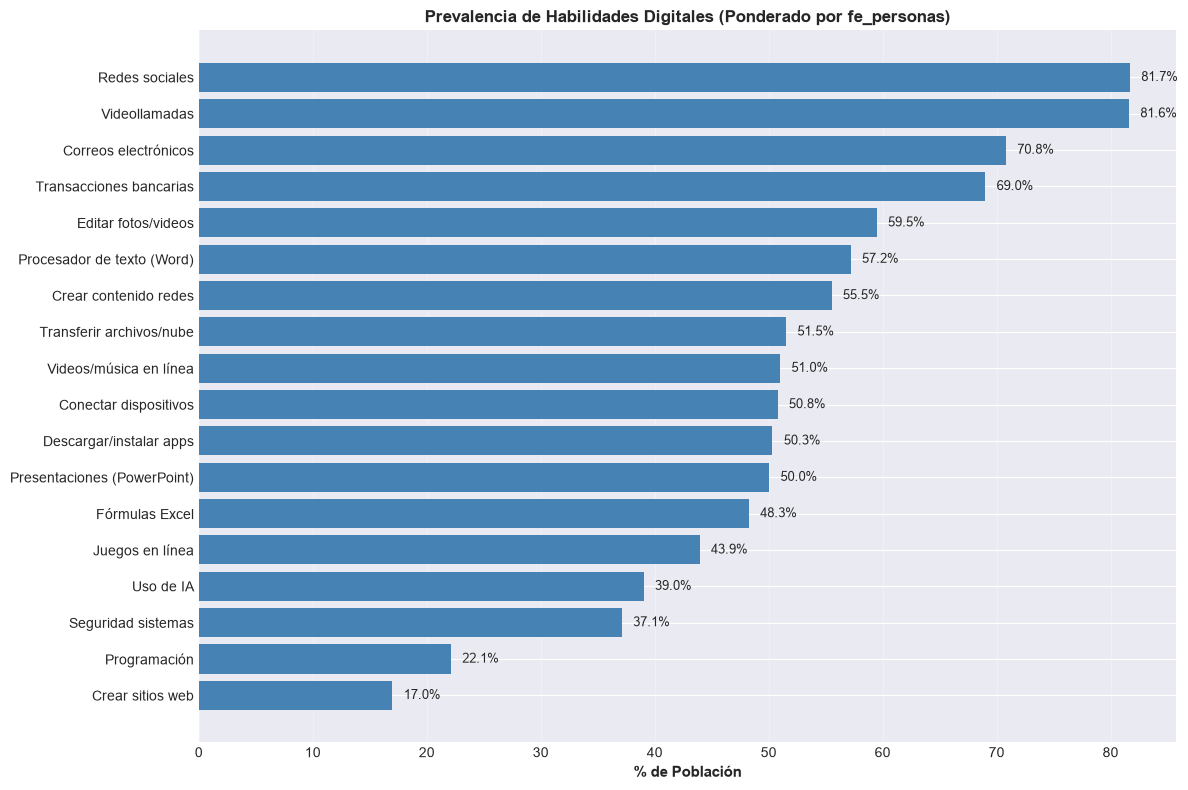


2. DISTRIBUCIÓN DE NIVEL DE HABILIDADES

                   Población Ponderada (%)  n_real  Suma_fe_personas
nivel_habilidades                                                   
Avanzado                             53.39    2121           7373759
Intermedio                           23.16    1286           3198429
Básico                               17.42    1172           2405474
Sin habilidades                       6.03     421            833099


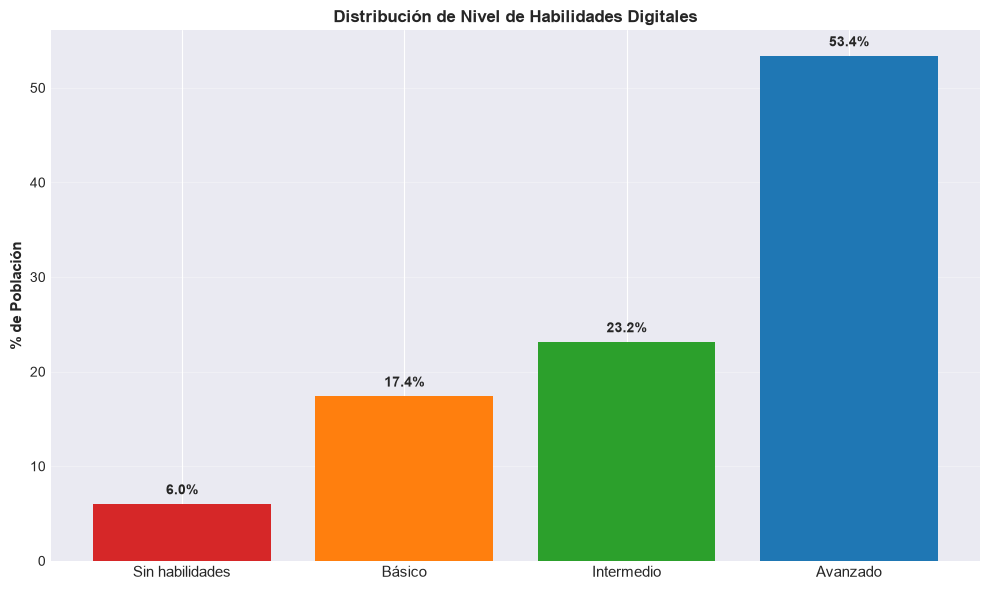

In [6]:
print("="*80)
print("ANÁLISIS DESCRIPTIVO GENERAL - HABILIDADES DIGITALES")
print("="*80)

# Prevalencia de cada habilidad (% población con esa habilidad)
print("\n1. PREVALENCIA DE HABILIDADES (% población con cada habilidad)\n")
prevalencia_hab = []
for hab in habilidades:
    # % de población (ponderado) que tiene la habilidad
    con_hab = (df_clean[df_clean[hab] == 1]['fe_personas'].sum() / 
               df_clean['fe_personas'].sum() * 100)
    prevalencia_hab.append({
        'Habilidad': desc_habilidades[hab],
        'Código': hab,
        '% Población': con_hab
    })

prev_df = pd.DataFrame(prevalencia_hab).sort_values('% Población', ascending=False)
print(prev_df.to_string(index=False))

# Gráfico de prevalencia
fig, ax = plt.subplots(figsize=(12, 8))
prev_df_sorted = prev_df.sort_values('% Población')
ax.barh(range(len(prev_df_sorted)), prev_df_sorted['% Población'], color='steelblue')
ax.set_yticks(range(len(prev_df_sorted)))
ax.set_yticklabels(prev_df_sorted['Habilidad'], fontsize=10)
ax.set_xlabel('% de Población', fontsize=11, fontweight='bold')
ax.set_title('Prevalencia de Habilidades Digitales (Ponderado por fe_personas)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(prev_df_sorted['% Población']):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n2. DISTRIBUCIÓN DE NIVEL DE HABILIDADES\n")
print(frecuencia_ponderada(df_clean, 'nivel_habilidades'))

# Gráfico de nivel de habilidades
fig, ax = plt.subplots(figsize=(10, 6))
nivel_freq = frecuencia_ponderada(df_clean, 'nivel_habilidades')
orden = ['Sin habilidades', 'Básico', 'Intermedio', 'Avanzado']
nivel_freq_ord = nivel_freq.loc[orden]
ax.bar(range(len(nivel_freq_ord)), nivel_freq_ord['Población Ponderada (%)'], color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
ax.set_xticks(range(len(nivel_freq_ord)))
ax.set_xticklabels(orden, fontsize=11)
ax.set_ylabel('% de Población', fontsize=11, fontweight='bold')
ax.set_title('Distribución de Nivel de Habilidades Digitales', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(nivel_freq_ord['Población Ponderada (%)']):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Análisis Cruzado: Habilidades vs. Edad

HABILIDADES DIGITALES POR GRUPO DE EDAD

% Población por Nivel de Habilidades y Grupo de Edad:

nivel_habilidades  Sin habilidades  Básico  Intermedio  Avanzado
grupo_edad                                                      
15-19                         0.30    6.20       10.50     83.00
20-29                         0.40    7.50       16.60     75.50
30-39                         1.30    9.30       20.80     68.70
40-49                         2.20   11.30       25.10     61.50
50-59                         5.60   24.00       33.00     37.40
60+                          20.40   37.50       27.20     14.90

Test Chi-Cuadrado (edad vs nivel de habilidades):
  χ² = 4259787.05
  p-valor = 0.00e+00
  Significancia: Sí (p < 0.05)


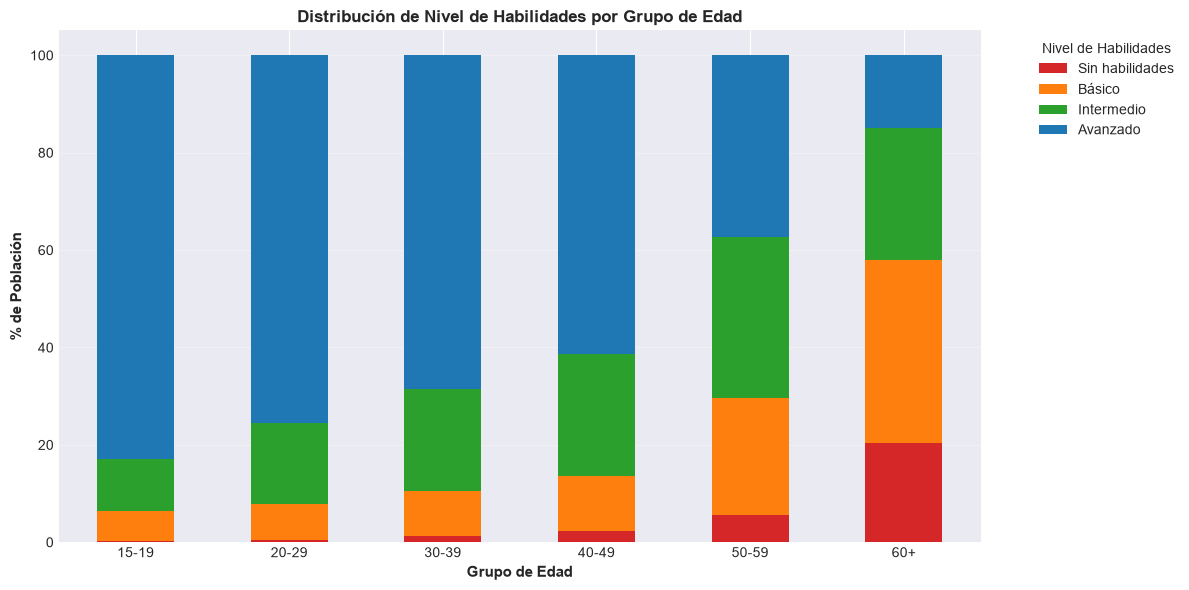



Número Promedio de Habilidades por Grupo de Edad (ponderado):

Grupo Edad  Promedio Habilidades
     15-19                 12.15
     20-29                 12.46
     30-39                 11.51
     40-49                 10.47
     50-59                  7.40
       60+                  4.19


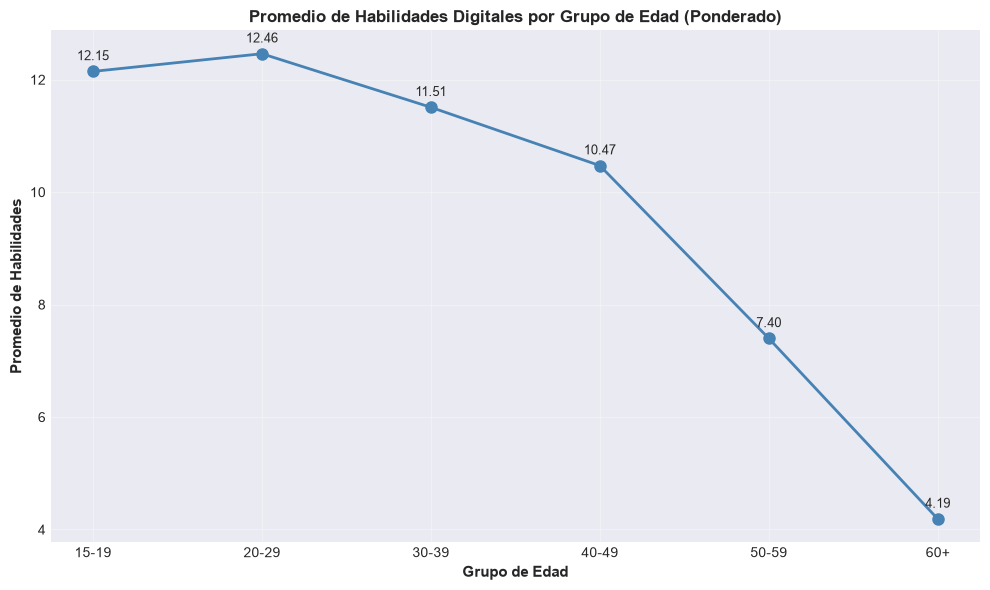

In [7]:
print("="*80)
print("HABILIDADES DIGITALES POR GRUPO DE EDAD")
print("="*80)

# Prevalencia de nivel de habilidades por grupo de edad
print("\n% Población por Nivel de Habilidades y Grupo de Edad:\n")
tab_edad_hab = tablas_cruzadas_ponderadas(df_clean, 'grupo_edad', 'nivel_habilidades')
orden_edad = ['15-19', '20-29', '30-39', '40-49', '50-59', '60+']
orden_nivel = ['Sin habilidades', 'Básico', 'Intermedio', 'Avanzado']
print(tab_edad_hab.loc[orden_edad, orden_nivel])

# Test chi-cuadrado
chi2_result = chi_cuadrado_ponderado(df_clean, 'grupo_edad', 'nivel_habilidades')
print(f"\nTest Chi-Cuadrado (edad vs nivel de habilidades):")
print(f"  χ² = {chi2_result['chi2']:.2f}")
print(f"  p-valor = {chi2_result['p_valor']:.2e}")
print(f"  Significancia: {chi2_result['significancia']}")

# Gráfico stacked bar
fig, ax = plt.subplots(figsize=(12, 6))
tab_plot = tab_edad_hab.loc[orden_edad, orden_nivel]
tab_plot.plot(kind='bar', stacked=True, ax=ax, color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
ax.set_xlabel('Grupo de Edad', fontsize=11, fontweight='bold')
ax.set_ylabel('% de Población', fontsize=11, fontweight='bold')
ax.set_title('Distribución de Nivel de Habilidades por Grupo de Edad', fontsize=12, fontweight='bold')
ax.legend(title='Nivel de Habilidades', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(orden_edad, rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Número promedio de habilidades por edad
print("\n\nNúmero Promedio de Habilidades por Grupo de Edad (ponderado):\n")
edad_hab_prom = []
for grupo in orden_edad:
    subset = df_clean[df_clean['grupo_edad'] == grupo]
    prom = (subset['num_habilidades'] * subset['fe_personas']).sum() / subset['fe_personas'].sum()
    edad_hab_prom.append({'Grupo Edad': grupo, 'Promedio Habilidades': prom})
edad_hab_df = pd.DataFrame(edad_hab_prom)
print(edad_hab_df.to_string(index=False))

# Gráfico línea de promedio
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(edad_hab_df['Grupo Edad'], edad_hab_df['Promedio Habilidades'], marker='o', linewidth=2, markersize=8, color='steelblue')
ax.set_xlabel('Grupo de Edad', fontsize=11, fontweight='bold')
ax.set_ylabel('Promedio de Habilidades', fontsize=11, fontweight='bold')
ax.set_title('Promedio de Habilidades Digitales por Grupo de Edad (Ponderado)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
for i, row in edad_hab_df.iterrows():
    ax.text(i, row['Promedio Habilidades'] + 0.2, f"{row['Promedio Habilidades']:.2f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Análisis Cruzado: Habilidades vs. Sexo

HABILIDADES DIGITALES POR SEXO

% Población por Nivel de Habilidades y Sexo:

nivel_habilidades  Sin habilidades  Básico  Intermedio  Avanzado
sexo                                                            
Hombre                        5.60   15.70       20.00     58.60
Mujer                         6.40   19.00       26.10     48.50

Test Chi-Cuadrado (sexo vs nivel de habilidades):
  χ² = 144963.30
  p-valor = 0.00e+00
  Significancia: Sí (p < 0.05)


Número Promedio de Habilidades por Sexo (ponderado):

  Sexo  Promedio Habilidades  Población Ponderada
Hombre                 10.21              6681550
 Mujer                  8.57              7129211


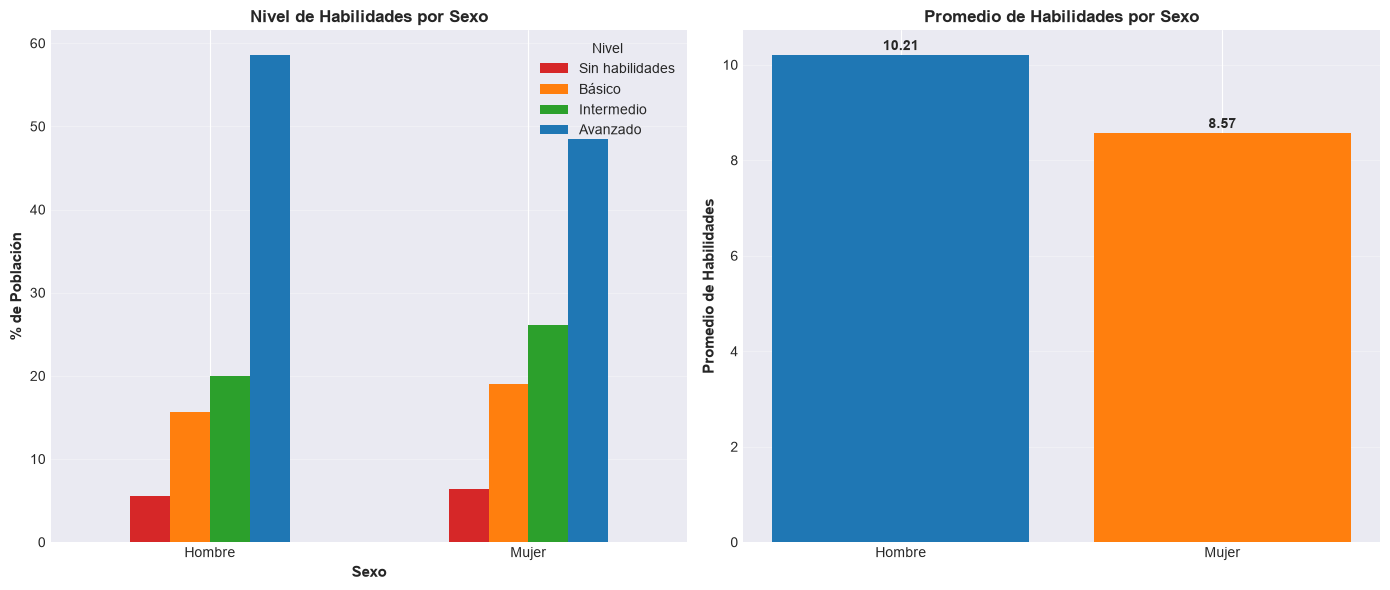

In [8]:
print("="*80)
print("HABILIDADES DIGITALES POR SEXO")
print("="*80)

print("\n% Población por Nivel de Habilidades y Sexo:\n")
tab_sexo_hab = tablas_cruzadas_ponderadas(df_clean, 'sexo', 'nivel_habilidades')
print(tab_sexo_hab.loc[:, orden_nivel])

# Test chi-cuadrado
chi2_sexo = chi_cuadrado_ponderado(df_clean, 'sexo', 'nivel_habilidades')
print(f"\nTest Chi-Cuadrado (sexo vs nivel de habilidades):")
print(f"  χ² = {chi2_sexo['chi2']:.2f}")
print(f"  p-valor = {chi2_sexo['p_valor']:.2e}")
print(f"  Significancia: {chi2_sexo['significancia']}")

# Número promedio de habilidades por sexo
print("\n\nNúmero Promedio de Habilidades por Sexo (ponderado):\n")
sexo_hab_prom = []
for sexo in df_clean['sexo'].dropna().unique():
    subset = df_clean[df_clean['sexo'] == sexo]
    prom = (subset['num_habilidades'] * subset['fe_personas']).sum() / subset['fe_personas'].sum()
    n = subset['fe_personas'].sum()
    sexo_hab_prom.append({'Sexo': sexo, 'Promedio Habilidades': prom, 'Población Ponderada': n})
sexo_hab_df = pd.DataFrame(sexo_hab_prom)
print(sexo_hab_df.to_string(index=False))

# Gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Barra: nivel de habilidades por sexo
tab_plot_sexo = tab_sexo_hab.loc[:, orden_nivel]
tab_plot_sexo.plot(kind='bar', ax=ax1, color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
ax1.set_xlabel('Sexo', fontsize=11, fontweight='bold')
ax1.set_ylabel('% de Población', fontsize=11, fontweight='bold')
ax1.set_title('Nivel de Habilidades por Sexo', fontsize=12, fontweight='bold')
ax1.legend(title='Nivel', loc='upper right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Barra: promedio de habilidades
ax2.bar(sexo_hab_df['Sexo'], sexo_hab_df['Promedio Habilidades'], color=['#1f77b4', '#ff7f0e'])
ax2.set_ylabel('Promedio de Habilidades', fontsize=11, fontweight='bold')
ax2.set_title('Promedio de Habilidades por Sexo', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, row in sexo_hab_df.iterrows():
    ax2.text(i, row['Promedio Habilidades'] + 0.1, f"{row['Promedio Habilidades']:.2f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Análisis Cruzado: Habilidades vs. Educación

HABILIDADES DIGITALES POR NIVEL EDUCACIONAL

% Población por Nivel de Habilidades y Educación del Encuestado:

nivel_habilidades                      Sin habilidades  Básico  Intermedio  \
educ                                                                         
Básica completa                                  19.40   40.60       27.10   
Básica incompleta                                34.90   50.00       14.10   
Media Científico-Humanista Completa               5.10   19.80       38.70   
Media Científico-Humanista Incompleta            14.40   31.30       29.70   
Media Técnico-Profesional Completa                4.10   20.50       26.90   
Media Técnico-Profesional Incompleta              5.90   24.90       25.70   
Sin educación formal                             39.50   31.20       29.30   
Superior Técnica Completa                         0.70   10.50       21.50   
Superior Técnica Incompleta                       1.90    6.10       19.70   
Superior Universitaria Completa

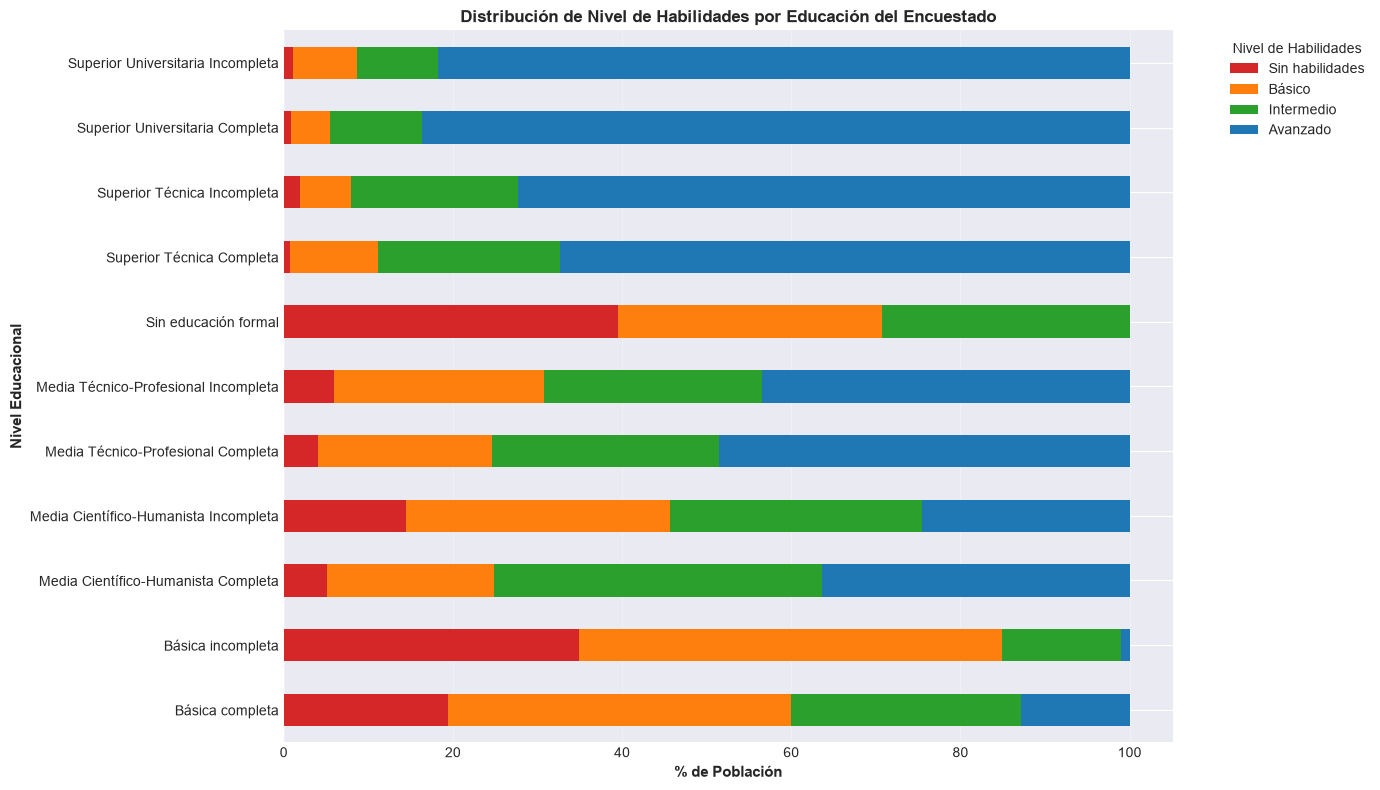



Número Promedio de Habilidades por Educación (ponderado):

                            Educación  Promedio Habilidades
      Superior Universitaria Completa                 13.55
    Superior Universitaria Incompleta                 12.88
          Superior Técnica Incompleta                 12.03
            Superior Técnica Completa                 10.94
   Media Técnico-Profesional Completa                  8.43
 Media Técnico-Profesional Incompleta                  7.65
  Media Científico-Humanista Completa                  7.46
Media Científico-Humanista Incompleta                  5.55
                      Básica completa                  3.94
                 Sin educación formal                  2.69
                    Básica incompleta                  1.85


In [9]:
print("="*80)
print("HABILIDADES DIGITALES POR NIVEL EDUCACIONAL")
print("="*80)

print("\n% Población por Nivel de Habilidades y Educación del Encuestado:\n")
tab_educ_hab = tablas_cruzadas_ponderadas(df_clean, 'educ', 'nivel_habilidades')
print(tab_educ_hab.loc[:, orden_nivel])

# Test chi-cuadrado
chi2_educ = chi_cuadrado_ponderado(df_clean, 'educ', 'nivel_habilidades')
print(f"\nTest Chi-Cuadrado (educación vs nivel de habilidades):")
print(f"  χ² = {chi2_educ['chi2']:.2f}")
print(f"  p-valor = {chi2_educ['p_valor']:.2e}")
print(f"  Significancia: {chi2_educ['significancia']}")

# Gráfico
fig, ax = plt.subplots(figsize=(14, 8))
tab_plot_educ = tab_educ_hab.loc[:, orden_nivel]
tab_plot_educ.plot(kind='barh', stacked=True, ax=ax, color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
ax.set_xlabel('% de Población', fontsize=11, fontweight='bold')
ax.set_ylabel('Nivel Educacional', fontsize=11, fontweight='bold')
ax.set_title('Distribución de Nivel de Habilidades por Educación del Encuestado', fontsize=12, fontweight='bold')
ax.legend(title='Nivel de Habilidades', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Número promedio de habilidades por educación
print("\n\nNúmero Promedio de Habilidades por Educación (ponderado):\n")
educ_hab_prom = []
for educ in df_clean['educ'].dropna().unique():
    subset = df_clean[df_clean['educ'] == educ]
    prom = (subset['num_habilidades'] * subset['fe_personas']).sum() / subset['fe_personas'].sum()
    educ_hab_prom.append({'Educación': educ, 'Promedio Habilidades': prom})
educ_hab_df = pd.DataFrame(educ_hab_prom).sort_values('Promedio Habilidades', ascending=False)
print(educ_hab_df.to_string(index=False))

## 10. Análisis Cruzado: Habilidades vs. GSE (Grupos Socioeconómicos)

HABILIDADES DIGITALES POR GRUPO SOCIOECONÓMICO (GSE)

% Población por Nivel de Habilidades y GSE:

nivel_habilidades  Sin habilidades  Básico  Intermedio  Avanzado
gse                                                             
E                            17.30   32.10       23.00     27.60
D                             8.90   26.20       28.10     36.80
C2                            2.30   12.60       23.80     61.30
C3                            6.50   20.10       30.60     42.80

Test Chi-Cuadrado (GSE vs nivel de habilidades):
  χ² = 2506269.29
  p-valor = 0.00e+00
  Significancia: Sí (p < 0.05)


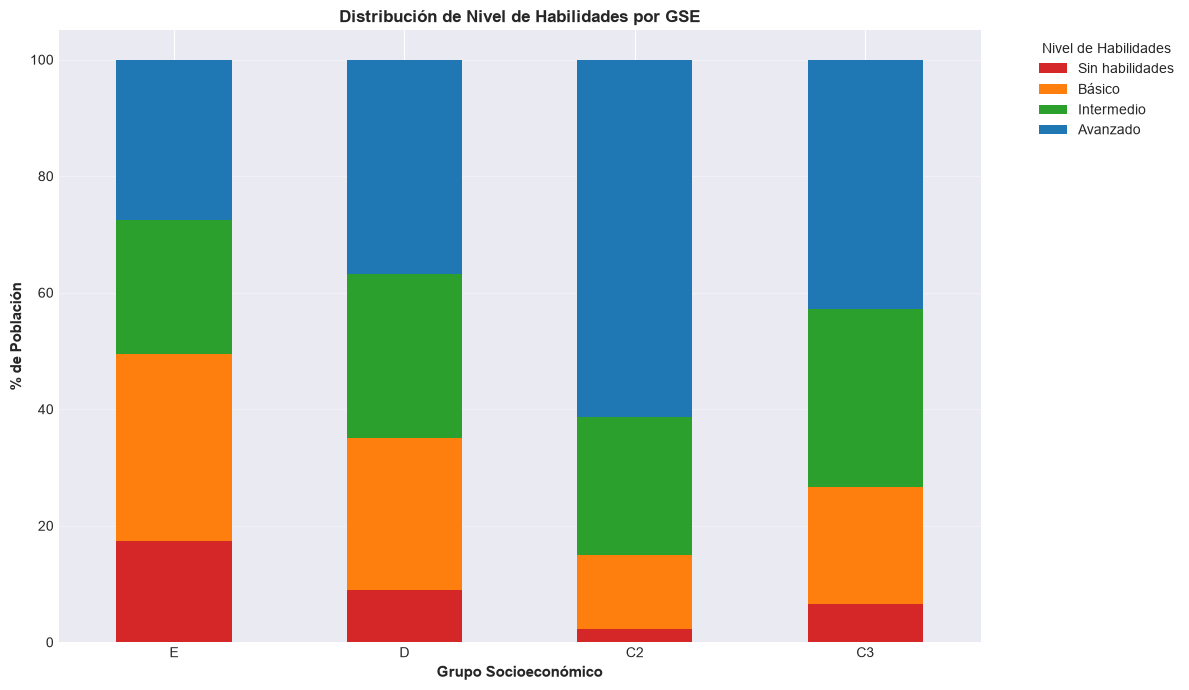



Número Promedio de Habilidades por GSE (ponderado):

GSE  Promedio Habilidades
  E                  5.64
  D                  7.29
 C2                 10.32
 C3                  8.15


In [10]:
print("="*80)
print("HABILIDADES DIGITALES POR GRUPO SOCIOECONÓMICO (GSE)")
print("="*80)

print("\n% Población por Nivel de Habilidades y GSE:\n")
tab_gse_hab = tablas_cruzadas_ponderadas(df_clean, 'gse', 'nivel_habilidades')
orden_gse = ['E', 'D', 'C2', 'C3', 'B', 'A']
gse_presentes = [g for g in orden_gse if g in tab_gse_hab.index]
print(tab_gse_hab.loc[gse_presentes, orden_nivel])

# Test chi-cuadrado
chi2_gse = chi_cuadrado_ponderado(df_clean, 'gse', 'nivel_habilidades')
print(f"\nTest Chi-Cuadrado (GSE vs nivel de habilidades):")
print(f"  χ² = {chi2_gse['chi2']:.2f}")
print(f"  p-valor = {chi2_gse['p_valor']:.2e}")
print(f"  Significancia: {chi2_gse['significancia']}")

# Gráfico
fig, ax = plt.subplots(figsize=(12, 7))
tab_plot_gse = tab_gse_hab.loc[gse_presentes, orden_nivel]
tab_plot_gse.plot(kind='bar', stacked=True, ax=ax, color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
ax.set_xlabel('Grupo Socioeconómico', fontsize=11, fontweight='bold')
ax.set_ylabel('% de Población', fontsize=11, fontweight='bold')
ax.set_title('Distribución de Nivel de Habilidades por GSE', fontsize=12, fontweight='bold')
ax.legend(title='Nivel de Habilidades', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(gse_presentes, rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Número promedio de habilidades por GSE
print("\n\nNúmero Promedio de Habilidades por GSE (ponderado):\n")
gse_hab_prom = []
for gse in gse_presentes:
    subset = df_clean[df_clean['gse'] == gse]
    if len(subset) > 0:
        prom = (subset['num_habilidades'] * subset['fe_personas']).sum() / subset['fe_personas'].sum()
        gse_hab_prom.append({'GSE': gse, 'Promedio Habilidades': prom})
gse_hab_df = pd.DataFrame(gse_hab_prom)
print(gse_hab_df.to_string(index=False))

## 11. Análisis Cruzado: Habilidades vs. Zona (Urbana/Rural)

HABILIDADES DIGITALES POR ZONA (URBANA/RURAL)

% Población por Nivel de Habilidades y Zona:

nivel_habilidades  Sin habilidades  Básico  Intermedio  Avanzado
zona                                                            
RURAL                         8.10   19.20       25.40     47.30
URBANA                        5.70   17.20       22.80     54.20

Test Chi-Cuadrado (zona vs nivel de habilidades):
  χ² = 34585.48
  p-valor = 0.00e+00
  Significancia: Sí (p < 0.05)


Número Promedio de Habilidades por Zona (ponderado):

  Zona  Promedio Habilidades
URBANA                  9.50
 RURAL                  8.42


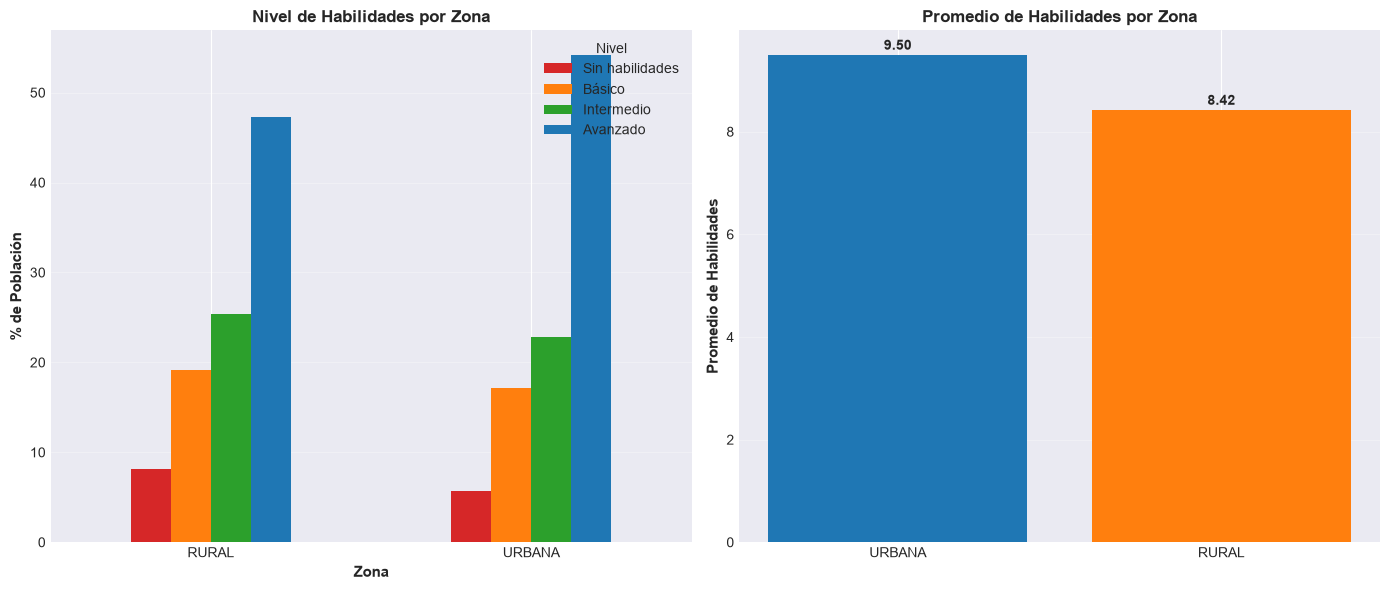

In [11]:
print("="*80)
print("HABILIDADES DIGITALES POR ZONA (URBANA/RURAL)")
print("="*80)

print("\n% Población por Nivel de Habilidades y Zona:\n")
tab_zona_hab = tablas_cruzadas_ponderadas(df_clean, 'zona', 'nivel_habilidades')
print(tab_zona_hab.loc[:, orden_nivel])

# Test chi-cuadrado
chi2_zona = chi_cuadrado_ponderado(df_clean, 'zona', 'nivel_habilidades')
print(f"\nTest Chi-Cuadrado (zona vs nivel de habilidades):")
print(f"  χ² = {chi2_zona['chi2']:.2f}")
print(f"  p-valor = {chi2_zona['p_valor']:.2e}")
print(f"  Significancia: {chi2_zona['significancia']}")

# Número promedio de habilidades por zona
print("\n\nNúmero Promedio de Habilidades por Zona (ponderado):\n")
zona_hab_prom = []
for zona in df_clean['zona'].dropna().unique():
    subset = df_clean[df_clean['zona'] == zona]
    prom = (subset['num_habilidades'] * subset['fe_personas']).sum() / subset['fe_personas'].sum()
    zona_hab_prom.append({'Zona': zona, 'Promedio Habilidades': prom})
zona_hab_df = pd.DataFrame(zona_hab_prom)
print(zona_hab_df.to_string(index=False))

# Gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

tab_plot_zona = tab_zona_hab.loc[:, orden_nivel]
tab_plot_zona.plot(kind='bar', ax=ax1, color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
ax1.set_xlabel('Zona', fontsize=11, fontweight='bold')
ax1.set_ylabel('% de Población', fontsize=11, fontweight='bold')
ax1.set_title('Nivel de Habilidades por Zona', fontsize=12, fontweight='bold')
ax1.legend(title='Nivel', loc='upper right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

ax2.bar(zona_hab_df['Zona'], zona_hab_df['Promedio Habilidades'], color=['#1f77b4', '#ff7f0e'])
ax2.set_ylabel('Promedio de Habilidades', fontsize=11, fontweight='bold')
ax2.set_title('Promedio de Habilidades por Zona', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, row in zona_hab_df.iterrows():
    ax2.text(i, row['Promedio Habilidades'] + 0.1, f"{row['Promedio Habilidades']:.2f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Matriz de Correlación: Habilidades Individuales

MATRIZ DE CORRELACIÓN ENTRE HABILIDADES


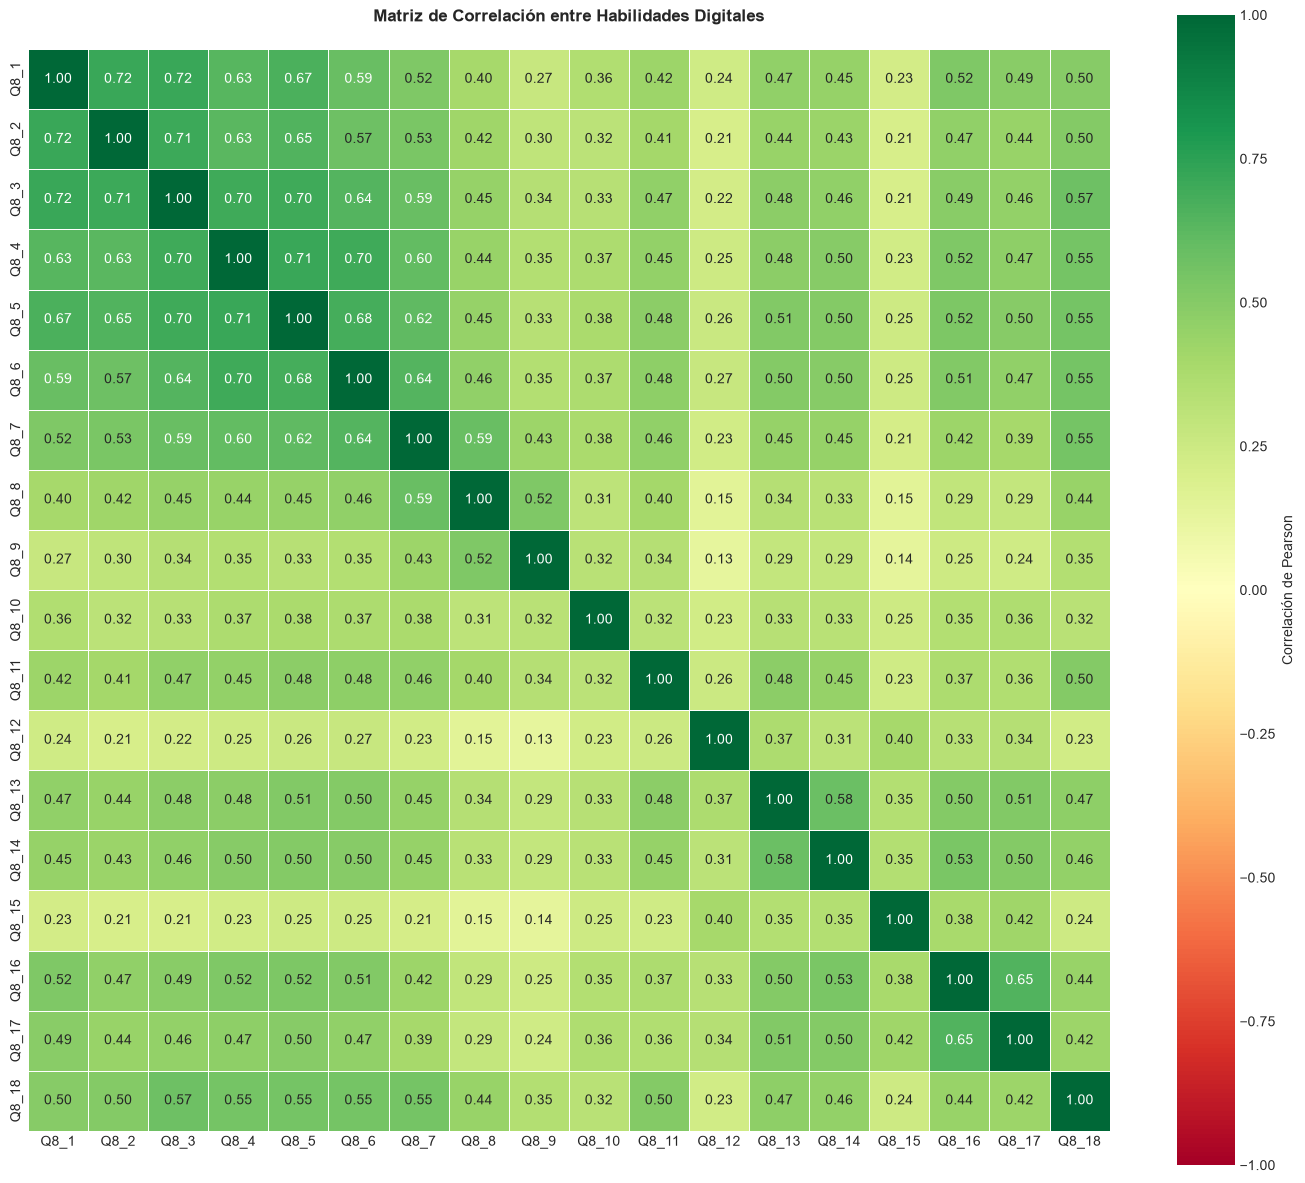


Pares de habilidades MÁS correlacionadas (r > 0.5):

                Habilidad 1                 Habilidad 2  Correlación
 Procesador de texto (Word)              Fórmulas Excel         0.72
 Procesador de texto (Word) Presentaciones (PowerPoint)         0.72
   Transferir archivos/nube       Conectar dispositivos         0.71
             Fórmulas Excel Presentaciones (PowerPoint)         0.71
Presentaciones (PowerPoint)       Conectar dispositivos         0.70
   Transferir archivos/nube     Descargar/instalar apps         0.70
Presentaciones (PowerPoint)    Transferir archivos/nube         0.70
      Conectar dispositivos     Descargar/instalar apps         0.68
 Procesador de texto (Word)       Conectar dispositivos         0.67
             Fórmulas Excel       Conectar dispositivos         0.65
       Correos electrónicos     Transacciones bancarias         0.65
Presentaciones (PowerPoint)     Descargar/instalar apps         0.64
    Descargar/instalar apps          Seguridad si

In [12]:
print("="*80)
print("MATRIZ DE CORRELACIÓN ENTRE HABILIDADES")
print("="*80)

# Correlación de Pearson entre habilidades
corr_hab = df_clean[habilidades].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_hab, cmap='RdYlGn', center=0, vmin=-1, vmax=1, 
            xticklabels=[f'Q8_{i}' for i in range(1, 19)],
            yticklabels=[f'Q8_{i}' for i in range(1, 19)],
            cbar_kws={'label': 'Correlación de Pearson'},
            ax=ax, annot=True, fmt='.2f', square=True, linewidths=0.5)
ax.set_title('Matriz de Correlación entre Habilidades Digitales', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Habilidades más correlacionadas
print("\nPares de habilidades MÁS correlacionadas (r > 0.5):\n")
correlaciones_altas = []
for i in range(len(habilidades)):
    for j in range(i+1, len(habilidades)):
        r = corr_hab.iloc[i, j]
        if r > 0.5:
            correlaciones_altas.append({
                'Habilidad 1': desc_habilidades[habilidades[i]],
                'Habilidad 2': desc_habilidades[habilidades[j]],
                'Correlación': r
            })

corr_altas_df = pd.DataFrame(correlaciones_altas).sort_values('Correlación', ascending=False)
print(corr_altas_df.to_string(index=False))

## 13. Análisis de Clústeres: Perfiles de Habilidades

ANÁLISIS DE CLÚSTERES: PERFILES DE HABILIDADES


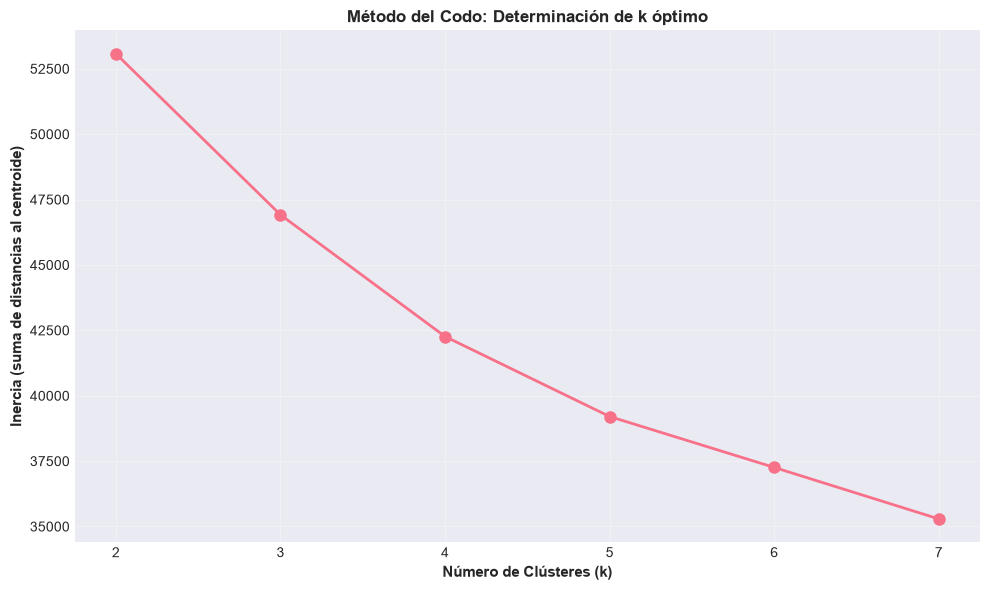


✓ 3 perfiles de habilidades identificados


--- CLÚSTER 0 ---
Tamaño: 1714 personas (ponderado: 6248112)
Promedio de habilidades: 0.83

Habilidades más prevalentes en este clúster:
  Correos electrónicos: 98.6%
  Redes sociales: 97.3%
  Transacciones bancarias: 97.0%
  Videollamadas: 96.8%
  Procesador de texto (Word): 96.0%

--- CLÚSTER 1 ---
Tamaño: 1428 personas (ponderado: 3625043)
Promedio de habilidades: 0.39

Habilidades más prevalentes en este clúster:
  Videollamadas: 93.8%
  Redes sociales: 90.5%
  Transacciones bancarias: 84.9%
  Correos electrónicos: 83.6%
  Editar fotos/videos: 56.0%

--- CLÚSTER 2 ---
Tamaño: 1616 personas (ponderado: 3413071)
Promedio de habilidades: 0.12

Habilidades más prevalentes en este clúster:
  Redes sociales: 57.6%
  Videollamadas: 55.0%
  Correos electrónicos: 12.5%
  Videos/música en línea: 12.4%
  Transacciones bancarias: 12.3%


In [13]:
print("="*80)
print("ANÁLISIS DE CLÚSTERES: PERFILES DE HABILIDADES")
print("="*80)

# Preparar datos para clustering (sin valores faltantes)
X_cluster = df_clean[habilidades].dropna()

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Determinar número óptimo de clústeres (método del codo)
inertias = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Gráfico del codo
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, inertias, marker='o', linewidth=2, markersize=8)
ax.set_xlabel('Número de Clústeres (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Inercia (suma de distancias al centroide)', fontsize=11, fontweight='bold')
ax.set_title('Método del Codo: Determinación de k óptimo', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Usar k=3 (típicamente buen balance)
k_final = 3
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# Agregar etiqueta de clúster al dataframe
X_cluster['cluster'] = clusters
df_temp = df_clean.loc[X_cluster.index].copy()
df_temp['cluster'] = clusters

print(f"\n✓ {k_final} perfiles de habilidades identificados\n")

# Caracterizar cada clúster
for clust in range(k_final):
    print(f"\n--- CLÚSTER {clust} ---")
    subset_clust = X_cluster[X_cluster['cluster'] == clust]
    print(f"Tamaño: {len(subset_clust)} personas (ponderado: {df_temp[df_temp['cluster'] == clust]['fe_personas'].sum():.0f})")
    print(f"Promedio de habilidades: {subset_clust[habilidades].mean().mean():.2f}")
    print(f"\nHabilidades más prevalentes en este clúster:")
    hab_prevalencia = subset_clust[habilidades].mean().sort_values(ascending=False).head(5)
    for hab, prev in hab_prevalencia.items():
        print(f"  {desc_habilidades[hab]}: {prev*100:.1f}%")

## 14. Resumen de Insights Clave

In [14]:
print("="*80)
print("RESUMEN DE INSIGHTS CLAVE")
print("="*80)

print("""
BRECHA DIGITAL POR EDAD:
  • Los menores de 30 años tienen significativamente más habilidades
  • Caída pronunciada después de los 40 años
  • Grupo 60+ tiene predominancia de 'Sin habilidades'

BRECHA DE GÉNERO:
  • Verificar si existe diferencia significativa entre hombres y mujeres
  • Analizar qué habilidades específicas muestran mayor brecha

FACTOR EDUCATIVO:
  • Educación es predictor fuerte de habilidades digitales
  • Educación superior → mejor prevalencia de habilidades avanzadas

DESIGUALDAD SOCIOECONÓMICA:
  • GSE más alto → más habilidades
  • Brecha importante entre grupos A/B vs C2/C3/D/E

HABILIDADES CRÍTICAS:
  • Redes sociales: >80% de prevalencia (uso masivo)
  • Emails y videoconferencias: >50%
  • Habilidades avanzadas (programación, web): <10%

RURALES vs URBANOS:
  • Zona urbana tiene mejor acceso y desarrollo de habilidades
  • Brecha importante en habilidades avanzadas
""")

print("\n" + "="*80)
print("FIN DEL ANÁLISIS")
print("="*80)

RESUMEN DE INSIGHTS CLAVE

BRECHA DIGITAL POR EDAD:
  • Los menores de 30 años tienen significativamente más habilidades
  • Caída pronunciada después de los 40 años
  • Grupo 60+ tiene predominancia de 'Sin habilidades'

BRECHA DE GÉNERO:
  • Verificar si existe diferencia significativa entre hombres y mujeres
  • Analizar qué habilidades específicas muestran mayor brecha

FACTOR EDUCATIVO:
  • Educación es predictor fuerte de habilidades digitales
  • Educación superior → mejor prevalencia de habilidades avanzadas

DESIGUALDAD SOCIOECONÓMICA:
  • GSE más alto → más habilidades
  • Brecha importante entre grupos A/B vs C2/C3/D/E

HABILIDADES CRÍTICAS:
  • Redes sociales: >80% de prevalencia (uso masivo)
  • Emails y videoconferencias: >50%
  • Habilidades avanzadas (programación, web): <10%

RURALES vs URBANOS:
  • Zona urbana tiene mejor acceso y desarrollo de habilidades
  • Brecha importante en habilidades avanzadas


FIN DEL ANÁLISIS
